# Paired-BRAM grid: `mark_bram(pair_within_stage=True)`, 11x11 + baseline (122 configs)

Sweeps the `mark_bram` predicate thresholds `(bw_in, bw_out)` over 0..10 on the
N=64 F=16 checkpoint at a 5 ns target on `xczu7ev`, packing two same-stage
same-geometry lookups per RAMB18. Produces `bram_paired_metrics.csv`, the
heatmap grid, and the paired-vs-unpaired comparison. Headline result:
`bram(7,5)` removes 16.8% of the LUTs at roughly the paper's clock with zero DSP.

**To run:** edit the config cell below — set `VIVADO_SETTINGS` to your
`settings64.sh`, `CHECKPOINT` to the model under `../../models/jsc_plf/64-16/`,
`UNPAIRED_CSV` to `../bram_grid_unpaired/sweep_metrics.csv`, and the
`HGQ_JSC150`/`DATA_DIR` paths to wherever the JSC dataset helpers live.
About 3 h wall-clock at `MAX_VIVADO_PAR=3`; set `RUN_VIVADO=False` to only
write the RTL projects.

In [1]:
import os
os.environ.setdefault('KERAS_BACKEND', 'jax')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.5')

import sys
from pathlib import Path

CHECKPOINT = Path('../../../models/jsc_plf/64-16/'
                  'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534.keras')
PARTICLES, FEATURES = 64, 16
PART_NAME   = 'xczu7ev-ffvc1156-2-e'
MODEL_NAME  = 'jsc'

CLOCK_PERIOD     = 5.0      # ns -> 200 MHz target (matches the unpaired grid)
CLOCK_UNCERTAINTY = 0.0
LATENCY_CUTOFF   = 3.1
TRACE_BATCH      = 2048
MAX_VIVADO_PAR   = 3
VIVADO_SETTINGS  = '/tools/Xilinx/2025.1/Vivado/settings64.sh'

BWIN_VALUES   = list(range(11))   # 0..10
BWOUT_VALUES  = list(range(11))
INCLUDE_NONE  = True
PAIR_WITHIN_STAGE = True

N_BITEXACT   = 256        # samples for the comb.predict bit-exact gate (every config)
RUN_VIVADO   = True

# Representative configs for the post-Vivado Verilator check (rtl.predict==comb.predict).
VERILATOR_CONFIGS = ['none', 'bwin_7_bwout_5', 'bwin_6_bwout_4']

# Existing unpaired grid metrics for the comparison plot.
UNPAIRED_CSV = Path('../bram_grid_unpaired/sweep_metrics.csv')

HGQ_JSC150 = Path('..').resolve()  # shared helpers: model.py, data.py, dump_bram.tcl
DATA_DIR   = Path('../../../dataset/jsc_plf').resolve()  # from prepare_datasets.sh
NB_DIR     = Path('.').resolve()
if str(HGQ_JSC150) not in sys.path:
    sys.path.insert(0, str(HGQ_JSC150))

def folder_for(bwin, bwout):
    return 'none' if bwin is None else f'bwin_{bwin}_bwout_{bwout}'

grid_points = [(bi, bo) for bi in BWIN_VALUES for bo in BWOUT_VALUES]
if INCLUDE_NONE:
    grid_points.append((None, None))

print(f'Grid          : {len(BWIN_VALUES)}x{len(BWOUT_VALUES)} + none = {len(grid_points)} configs')
print(f'pair_within_stage = {PAIR_WITHIN_STAGE}')
print(f'Part / clock  : {PART_NAME}  T={CLOCK_PERIOD} ns  cutoff={LATENCY_CUTOFF} ns')
print(f'Output dir    : {NB_DIR}')


Grid          : 11x11 + none = 122 configs
pair_within_stage = True
Part / clock  : xczu7ev-ffvc1156-2-e  T=5.0 ns  cutoff=3.1 ns
Output dir    : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/track1_bram_paired


Load the cached pre-traced checkpoint.

In [2]:
import keras
from model import SameDim0
from data import get_data
from hgq.utils import trace_minmax

raw_ckpt = CHECKPOINT.expanduser().resolve()
traced   = raw_ckpt.parent / f'model_traced_n{PARTICLES}_f{FEATURES}.keras'
if not traced.exists():
    print('Running trace_minmax (first run only)...')
    m0 = keras.models.load_model(raw_ckpt, compile=False, custom_objects={'SameDim0': SameDim0})
    (Xtr, _), (Xv, _), _ = get_data(DATA_DIR, PARTICLES, FEATURES == 3)
    trace_minmax(m0, Xtr, batch_size=TRACE_BATCH, reset=True,  verbose=True)
    trace_minmax(m0, Xv,  batch_size=TRACE_BATCH, reset=False, verbose=True)
    m0.save(traced)
model = keras.models.load_model(traced, compile=False, custom_objects={'SameDim0': SameDim0})
model_stem = raw_ckpt.stem
print(f'Loaded N={model.input_shape[1]} F={model.input_shape[-1]}')

# Fixed bit-exact test batch (validation set head).
(_, _), (Xval, _), (Xtest, ytest) = get_data(DATA_DIR, PARTICLES, FEATURES == 3)
import numpy as np
X_BE = np.asarray(Xval)[:N_BITEXACT]
print(f'Bit-exact test batch: {X_BE.shape}')


Loaded N=64 F=16
Bit-exact test batch: (256, 64, 16)


Trace once; the unmarked `comb_base.predict` is the bit-exact reference for every config.

In [3]:
import numpy as np
from da4ml.converter import trace_model
from da4ml.trace import HWConfig, comb_trace, mark_bram

HW_CONFIG      = HWConfig(1, -1, -1)
SOLVER_OPTIONS = {'hard_dc': 2}

def _trace_base():
    inp, out = trace_model(model, hwconf=HW_CONFIG, solver_options=SOLVER_OPTIONS, verbose=False)
    return comb_trace(inp, out)

comb_base = _trace_base()
max_lat = max(op.latency for op in comb_base.ops)
print(f'max(comb_base.latency) = {max_lat}  (expect ~33)')
assert max_lat < 50

BASELINE_PRED = comb_base.predict(X_BE, n_threads=-1)
print(f'baseline pred shape {BASELINE_PRED.shape} — reference for bit-exact gate')


max(comb_base.latency) = 33.0  (expect ~33)
baseline pred shape (256, 5) — reference for bit-exact gate


Per grid point: mark, write RTL, count emitted BRAM modules, assert bit-exactness.

In [4]:
import shutil, re
from da4ml.codegen import RTLModel

def _count_modules(src_dir):
    txt = ''.join(p.read_text() for p in src_dir.glob('jsc_stage*.v'))
    n_pair   = len(re.findall(r'\blookup_table_block_paired\b', txt))
    n_single = len(re.findall(r'\blookup_table_block\b(?!_paired)', txt))
    return n_pair, n_single

records = []
n_fail_be = 0
for k, (bwin, bwout) in enumerate(grid_points):
    folder = folder_for(bwin, bwout)
    out_path = NB_DIR / folder / model_stem
    if (NB_DIR / folder).exists():
        shutil.rmtree(NB_DIR / folder)
    out_path.mkdir(parents=True, exist_ok=True)

    comb = _trace_base()
    if bwin is not None:
        comb = mark_bram(
            comb,
            predicate=lambda bw_in, bw_out, ti=bwin, to=bwout: bw_in >= ti and bw_out >= to,
            latency_cutoff=LATENCY_CUTOFF,
            pair_within_stage=PAIR_WITHIN_STAGE,
        )
    # Bit-exact gate (control #5).
    pred = comb.predict(X_BE, n_threads=-1)
    be_ok = bool(np.all(pred == BASELINE_PRED))
    if not be_ok:
        n_fail_be += 1

    rtl = RTLModel(comb, MODEL_NAME, str(out_path),
                   latency_cutoff=LATENCY_CUTOFF, clock_period=CLOCK_PERIOD,
                   part_name=PART_NAME, clock_uncertainty=CLOCK_UNCERTAINTY)
    rtl.write()
    n_pair, n_single = _count_modules(out_path / 'src')
    n_bram = sum(1 for op in comb.ops if op.opcode == 8 and (op.data >> 32) & 1)
    lat = max(op.latency for op in comb.ops)

    records.append(dict(folder=folder, bwin=bwin, bwout=bwout,
                        prj_dir=out_path, n_pair=n_pair, n_single=n_single,
                        n_bram=n_bram, ir_latency=float(lat), bit_exact=be_ok))
    flag = 'OK ' if be_ok else '!!FAIL!!'
    if k % 11 == 0 or not be_ok:
        print(f'[{k+1:3d}/{len(grid_points)}] {folder:<18s} bram={n_bram:<4d} '
              f'pair={n_pair:<4d} single={n_single:<4d} bit_exact={flag}')

print(f'\nBuilt {len(records)} configs. bit-exact failures: {n_fail_be}')
assert n_fail_be == 0, 'BIT-EXACT FAILURE — mark_bram changed outputs!'
print('✓ All configs bit-exact vs unmarked baseline (comb.predict).')


[  1/122] bwin_0_bwout_0     bram=3819 pair=1796 single=227  bit_exact=OK 
[ 12/122] bwin_1_bwout_0     bram=3819 pair=1796 single=227  bit_exact=OK 
[ 23/122] bwin_2_bwout_0     bram=3763 pair=1772 single=219  bit_exact=OK 
[ 34/122] bwin_3_bwout_0     bram=3468 pair=1635 single=198  bit_exact=OK 
[ 45/122] bwin_4_bwout_0     bram=2994 pair=1419 single=156  bit_exact=OK 
[ 56/122] bwin_5_bwout_0     bram=2129 pair=998  single=133  bit_exact=OK 
[ 67/122] bwin_6_bwout_0     bram=1201 pair=557  single=87   bit_exact=OK 
[ 78/122] bwin_7_bwout_0     bram=575  pair=257  single=61   bit_exact=OK 
[ 89/122] bwin_8_bwout_0     bram=217  pair=91   single=35   bit_exact=OK 
[100/122] bwin_9_bwout_0     bram=49   pair=17   single=15   bit_exact=OK 
[111/122] bwin_10_bwout_0    bram=8    pair=1    single=6    bit_exact=OK 
[122/122] none               bram=0    pair=0    single=0    bit_exact=OK 

Built 122 configs. bit-exact failures: 0
✓ All configs bit-exact vs unmarked baseline (comb.predict

Guard: stage file count must match the IR latency (catches stale files).

In [5]:
import json, re
pat = re.compile(r'jsc_stage(\d+)\.v$')
bad = []
for r in records:
    src = r['prj_dir'] / 'src'
    meta = json.loads((r['prj_dir'] / 'metadata.json').read_text())
    n_v = sum(1 for vf in src.glob('jsc_stage*.v') if pat.search(vf.name))
    if n_v != meta['latency']:
        bad.append((r['folder'], n_v, meta['latency']))
if bad:
    for f, n, l in bad: print(f'!! {f}: {n} != {l}')
    raise AssertionError('stale files')
print(f'All {len(records)} configs consistent (stage_files == metadata.latency).')


All 122 configs consistent (stage_files == metadata.latency).


Run Vivado on all 122 projects, 3 concurrent (~3 h).

In [6]:
import shlex, subprocess, time
from collections import deque

def start_job(tcl):
    rd = tcl.parent
    of = open(rd / 'vivado_stdout.log', 'w'); ef = open(rd / 'vivado_stderr.log', 'w')
    cmd = (f'set -e\nsource {shlex.quote(VIVADO_SETTINGS)}\n'
           f'vivado -mode batch -source {shlex.quote(str(tcl.resolve()))} -nojournal -nolog\n')
    p = subprocess.Popen(['bash', '-lc', cmd], cwd=str(rd), stdout=of, stderr=ef, text=True)
    return dict(rd=rd, p=p, of=of, ef=ef, t0=time.time())

if RUN_VIVADO:
    tcls = [r['prj_dir'] / 'build_vivado_prj.tcl' for r in records]
    q = deque(tcls); running = []; done = []
    def drain():
        while q and len(running) < MAX_VIVADO_PAR:
            j = start_job(q.popleft()); running.append(j)
            print(f'[START] {j["rd"].parent.name}')
    drain()
    while running:
        time.sleep(1.0)
        for j in list(running):
            rc = j['p'].poll()
            if rc is None: continue
            j['of'].close(); j['ef'].close()
            print(f'[{"OK" if rc==0 else f"rc={rc}"}] {j["rd"].parent.name}  t={time.time()-j["t0"]:.0f}s')
            done.append((j['rd'].parent.name, rc)); running.remove(j); drain()
    print(f'\nVivado done {len(done)}/{len(tcls)}; nonzero rc: {[d for d in done if d[1]!=0] or "none"}')
else:
    print('RUN_VIVADO=False — skipping.')


[START] bwin_0_bwout_0
[START] bwin_0_bwout_1
[START] bwin_0_bwout_2
[rc=1] bwin_0_bwout_2  t=336s
[START] bwin_0_bwout_3
[rc=1] bwin_0_bwout_0  t=382s
[START] bwin_0_bwout_4
[rc=1] bwin_0_bwout_1  t=382s
[START] bwin_0_bwout_5
[rc=1] bwin_0_bwout_3  t=267s
[START] bwin_0_bwout_6
[rc=1] bwin_0_bwout_4  t=290s
[START] bwin_0_bwout_7
[OK] bwin_0_bwout_5  t=375s
[START] bwin_0_bwout_8
[OK] bwin_0_bwout_6  t=376s
[START] bwin_0_bwout_9
[OK] bwin_0_bwout_7  t=376s
[START] bwin_0_bwout_10
[OK] bwin_0_bwout_8  t=348s
[START] bwin_1_bwout_0
[OK] bwin_0_bwout_9  t=360s
[START] bwin_1_bwout_1
[OK] bwin_0_bwout_10  t=370s
[START] bwin_1_bwout_2
[rc=1] bwin_1_bwout_0  t=379s
[START] bwin_1_bwout_3
[rc=1] bwin_1_bwout_1  t=382s
[START] bwin_1_bwout_4
[rc=1] bwin_1_bwout_3  t=253s
[START] bwin_1_bwout_5
[rc=1] bwin_1_bwout_2  t=326s
[START] bwin_1_bwout_6
[rc=1] bwin_1_bwout_4  t=289s
[START] bwin_1_bwout_7
[OK] bwin_1_bwout_5  t=380s
[START] bwin_1_bwout_8
[OK] bwin_1_bwout_6  t=373s
[START] bwin_1

Verilator check on a representative subset: emitted RTL matches `comb.predict` bit-for-bit.

In [7]:
import tempfile, shutil
import numpy as np
from da4ml.codegen import RTLModel
from da4ml.trace import mark_bram

def _comb_for(bwin, bwout):
    comb = _trace_base()
    if bwin is not None:
        comb = mark_bram(comb,
                         predicate=lambda a, b, ti=bwin, to=bwout: a >= ti and b >= to,
                         latency_cutoff=LATENCY_CUTOFF, pair_within_stage=PAIR_WITHIN_STAGE)
    return comb

def _parse_folder(name):
    if name == 'none': return None, None
    m = re.match(r'bwin_(\d+)_bwout_(\d+)', name)
    return int(m.group(1)), int(m.group(2))

scratch = Path(tempfile.mkdtemp(prefix='track1_paired_veri_'))
n_checked = 0
try:
    for cfg in VERILATOR_CONFIGS:
        bwin, bwout = _parse_folder(cfg)
        comb = _comb_for(bwin, bwout)
        sw = comb.predict(X_BE, n_threads=-1)
        op = scratch / cfg
        op.mkdir(parents=True, exist_ok=True)
        rtl = RTLModel(comb, MODEL_NAME, str(op), latency_cutoff=LATENCY_CUTOFF,
                       clock_period=CLOCK_PERIOD, part_name=PART_NAME, clock_uncertainty=0.0)
        rtl.write()
        for _ in range(8):
            try:
                rtl._compile(openmp=False, nproc=4); break
            except RuntimeError:
                pass
        hw = rtl.predict(X_BE)
        ndiff = int(np.sum(hw != sw))
        print(f'  {cfg:<18s}: rtl(verilator) vs comb(SW) diffs = {ndiff} / {hw.size}')
        assert ndiff == 0, f'{cfg}: Verilator != SW IR!'
        n_checked += 1
    print(f'\n✓ Verilator bit-accuracy passed on {n_checked} representative config(s).')
finally:
    shutil.rmtree(scratch, ignore_errors=True)


  none              : rtl(verilator) vs comb(SW) diffs = 0 / 1280
  bwin_7_bwout_5    : rtl(verilator) vs comb(SW) diffs = 0 / 1280
  bwin_6_bwout_4    : rtl(verilator) vs comb(SW) diffs = 0 / 1280

✓ Verilator bit-accuracy passed on 3 representative config(s).


Parse post-route reports into `bram_paired_metrics.csv`.

In [8]:
import json, re
import numpy as np
import pandas as pd

def _used(t, label):
    m = re.search(r'^\|\s*' + re.escape(label) + r'\s*\|\s*([\d.]+)\s*\|', t, re.MULTILINE)
    return float(m.group(1)) if m else float('nan')

def _wns(path):
    if not path.exists(): return float('nan')
    m = re.search(r'WNS\(ns\)[^\n]*\n[^\n]*\n\s*([-\d.]+)', path.read_text())
    return float(m.group(1)) if m else float('nan')

rows = []
for r in records:
    rep = r['prj_dir'] / 'output_jsc' / 'reports'
    util = rep / 'jsc_post_route_util.rpt'
    meta = json.loads((r['prj_dir'] / 'metadata.json').read_text())
    cyc = meta.get('latency', float('nan'))
    have = util.exists()
    t = util.read_text() if have else ''
    wpp = _wns(rep / 'jsc_post_place_timing.rpt')
    wpr = _wns(rep / 'jsc_post_route_timing.rpt')
    fpp = 1000.0/(CLOCK_PERIOD-wpp) if wpp==wpp and (CLOCK_PERIOD-wpp)>0 else float('nan')
    fpr = 1000.0/(CLOCK_PERIOD-wpr) if wpr==wpr and (CLOCK_PERIOD-wpr)>0 else float('nan')
    lat_ns = cyc*(CLOCK_PERIOD-wpr) if wpr==wpr else float('nan')
    if not have:
        status = 'place_fail'
    elif wpr==wpr and wpr < 0:
        status = 'routing_fail'
    elif wpr==wpr:
        status = 'met'
    else:
        status = 'no_timing'
    rows.append(dict(
        config=r['folder'], bw_in_threshold=r['bwin'], bw_out_threshold=r['bwout'],
        pair_within_stage=PAIR_WITHIN_STAGE,
        lut_total=_used(t,'CLB LUTs'), lut_logic=_used(t,'LUT as Logic'),
        lut_memory=_used(t,'LUT as Memory'), ff=_used(t,'CLB Registers'),
        bram_tile=_used(t,'Block RAM Tile'), bram_ramb18_used=_used(t,'RAMB18'),
        bram_ramb36_used=_used(t,'RAMB36/FIFO*'), dsp=_used(t,'DSPs'),
        cycles=cyc, latency_ns=lat_ns,
        wns_pp=wpp, fmax_pp_MHz=fpp, wns_pr=wpr, fmax_pr_MHz=fpr,
        status=status, bit_exact_passed=r['bit_exact'],
        n_paired_modules=r['n_pair'], n_single_modules=r['n_single'],
    ))

df = pd.DataFrame(rows)
if df['lut_total'].notna().any():
    df.to_csv(NB_DIR / 'bram_paired_metrics.csv', index=False)
else:
    # No Vivado reports on disk: keep the committed results instead of clobbering them.
    df = pd.read_csv(NB_DIR / 'bram_paired_metrics.csv')
    print('no Vivado reports found; loaded committed bram_paired_metrics.csv')
n_met = int((df['status']=='met').sum())
print(f'Wrote bram_paired_metrics.csv ({len(df)} rows; {n_met} timing-met)')
print(df[['config','lut_total','bram_tile','n_paired_modules','n_single_modules',
          'cycles','fmax_pr_MHz','wns_pr','status','bit_exact_passed']]
      .head(15).to_string(index=False))


Wrote bram_paired_metrics.csv (122 rows; 90 timing-met)
         config  lut_total  bram_tile  n_paired_modules  n_single_modules  cycles  fmax_pr_MHz  wns_pr     status  bit_exact_passed
 bwin_0_bwout_0        NaN        NaN              1796               227      35          NaN     NaN place_fail              True
 bwin_0_bwout_1        NaN        NaN              1796               227      35          NaN     NaN place_fail              True
 bwin_0_bwout_2        NaN        NaN              1444               206      34          NaN     NaN place_fail              True
 bwin_0_bwout_3        NaN        NaN               972               193      35          NaN     NaN place_fail              True
 bwin_0_bwout_4        NaN        NaN               609               154      34          NaN     NaN place_fail              True
 bwin_0_bwout_5    30741.0      227.5               332               124      29   224.014337   0.536        met              True
 bwin_0_bwout_6    3

Heatmaps over the `(bw_in, bw_out)` grid.

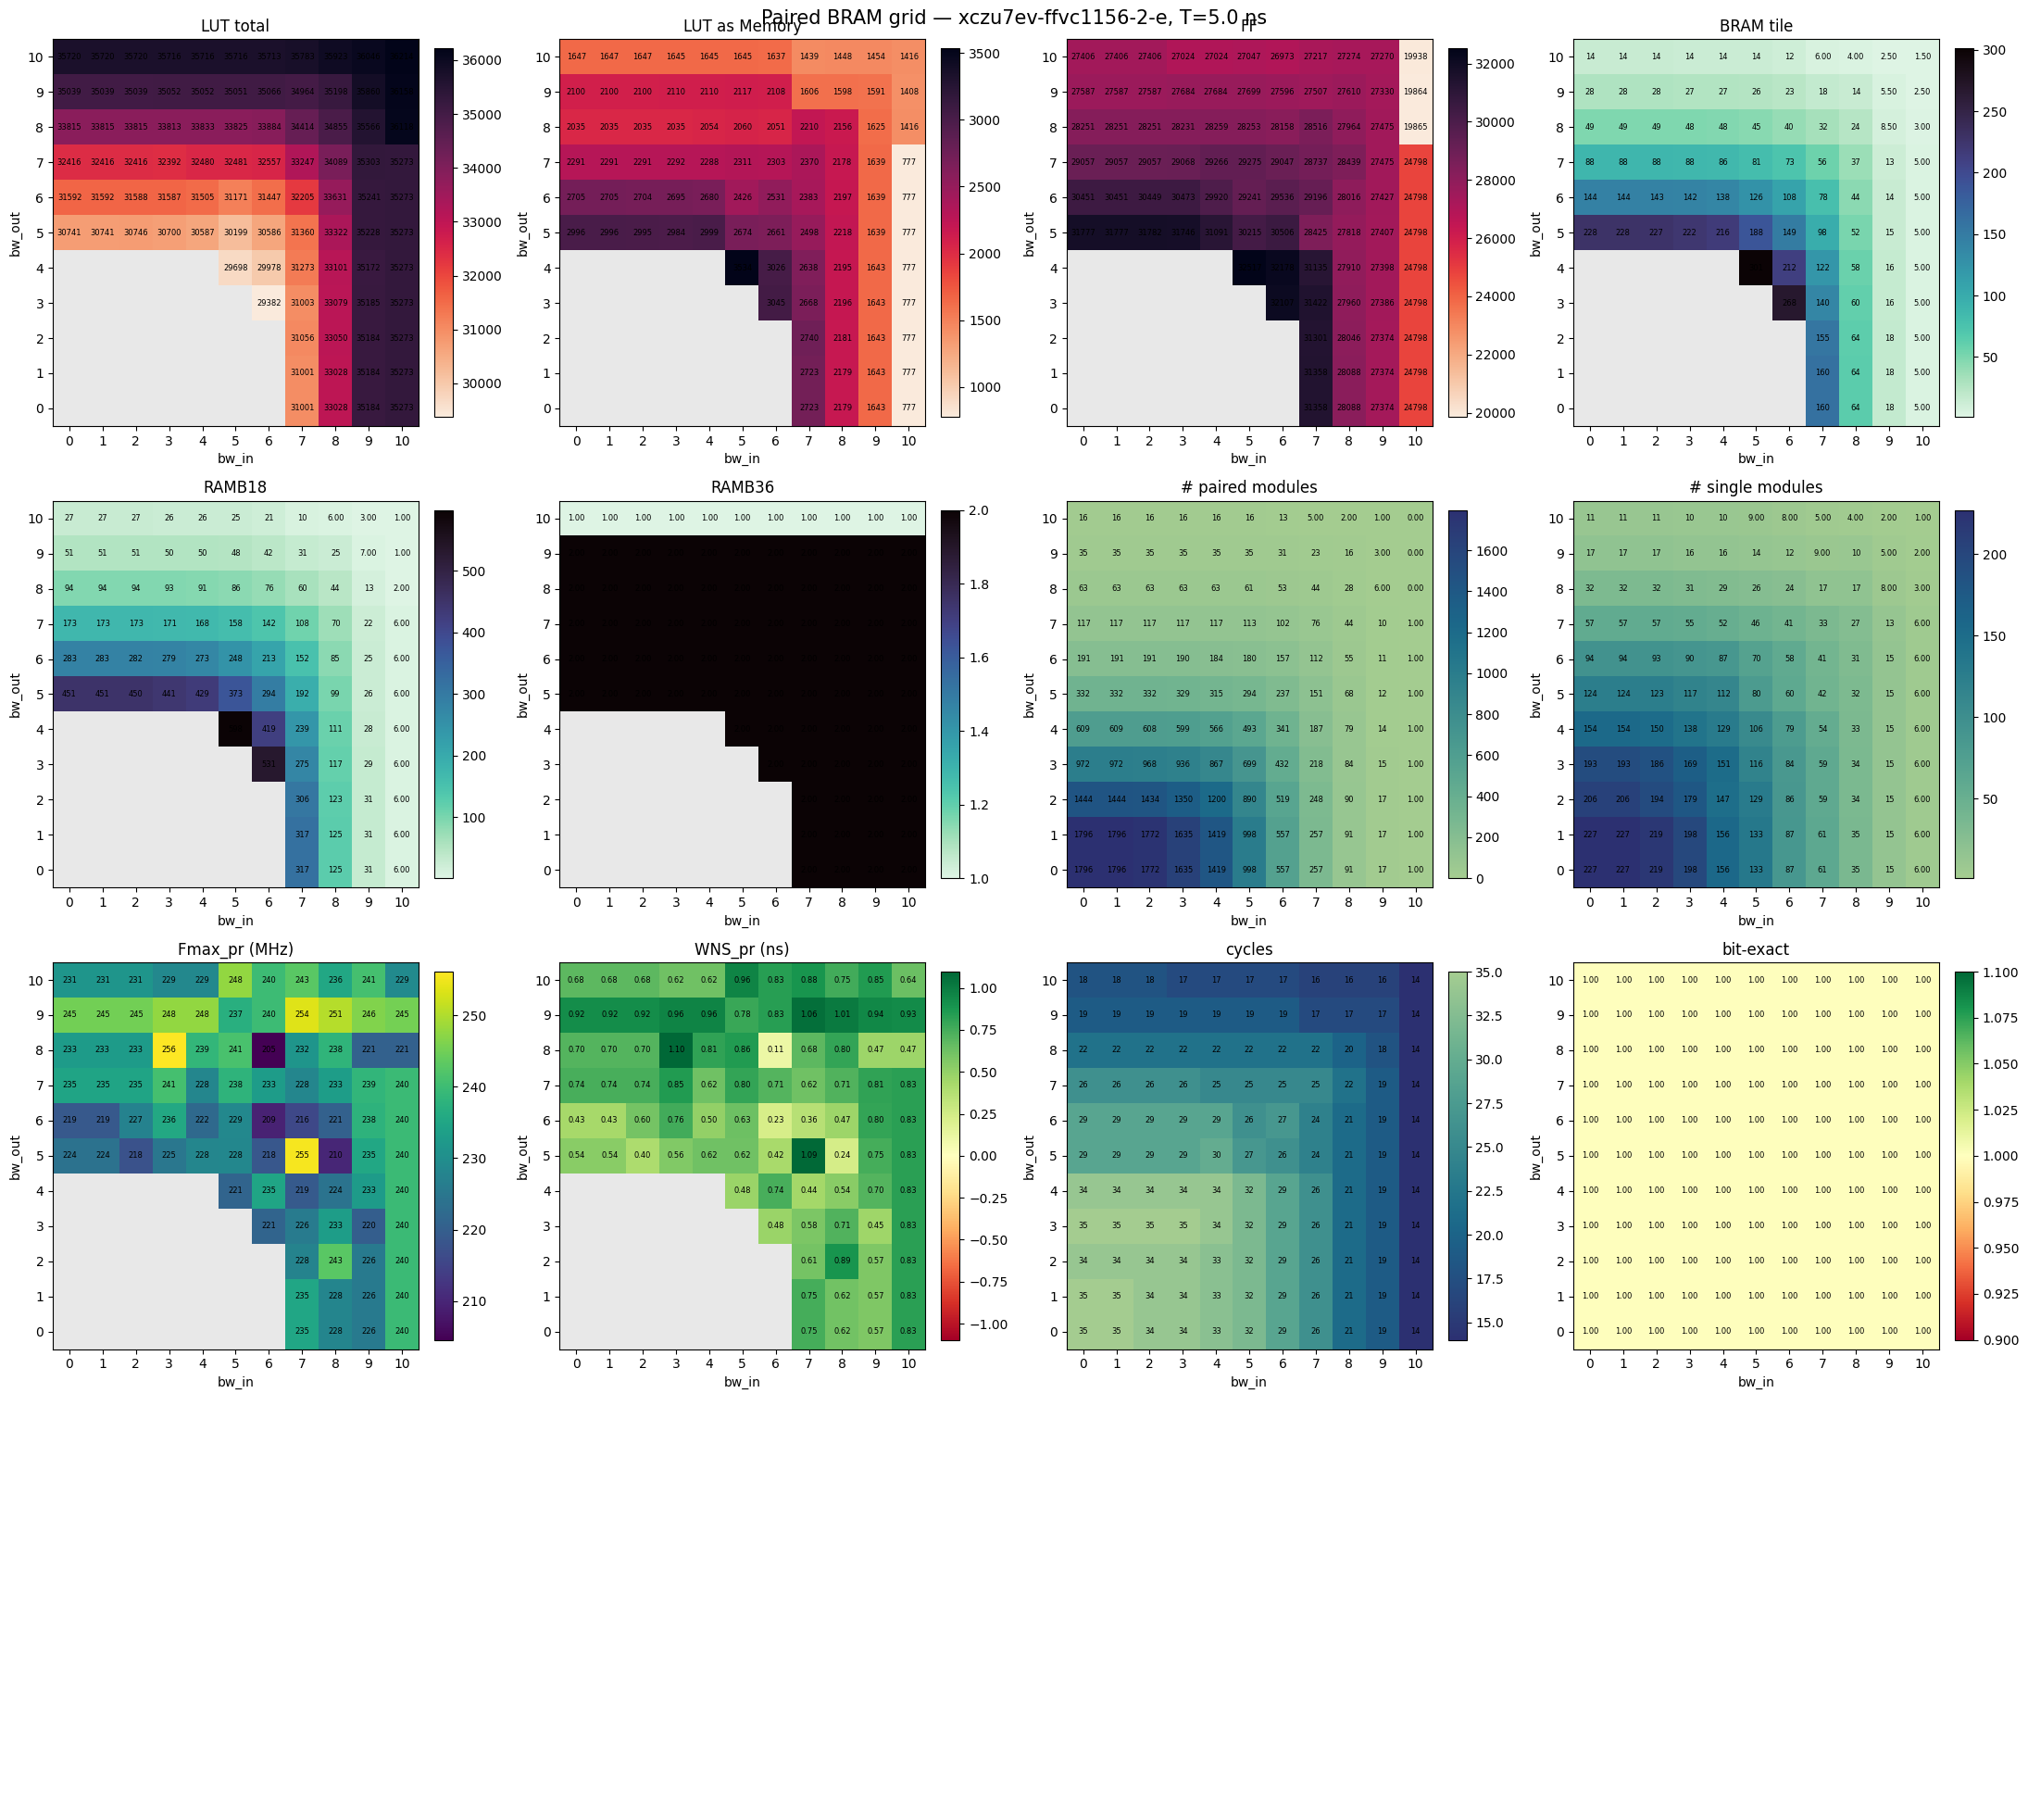

Saved bram_paired_heatmaps.png


In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

g = df[df['config'] != 'none'].copy()
g['bw_in_threshold'] = g['bw_in_threshold'].astype(int)
g['bw_out_threshold'] = g['bw_out_threshold'].astype(int)

metrics = [
    ('lut_total','LUT total','rocket_r'), ('lut_memory','LUT as Memory','rocket_r'),
    ('ff','FF','rocket_r'), ('bram_tile','BRAM tile','mako_r'),
    ('bram_ramb18_used','RAMB18','mako_r'), ('bram_ramb36_used','RAMB36','mako_r'),
    ('n_paired_modules','# paired modules','crest'), ('n_single_modules','# single modules','crest'),
    ('fmax_pr_MHz','Fmax_pr (MHz)','viridis'), ('wns_pr','WNS_pr (ns)','RdYlGn'),
    ('cycles','cycles','crest_r'), ('bit_exact_passed','bit-exact','RdYlGn'),
]
try:
    import seaborn as sns
    cmap = lambda n: sns.color_palette(n, as_cmap=True)
except ImportError:
    cmap = lambda n: mpl.colormaps.get(n, mpl.colormaps['viridis'])

fig, axes = plt.subplots(4, 4, figsize=(22, 20))
axes = axes.flatten()
for ax,(col,title,cm) in zip(axes, metrics):
    piv = g.pivot(index='bw_out_threshold', columns='bw_in_threshold', values=col).sort_index(ascending=False)
    vals = piv.values.astype(float)
    c = cmap(cm).copy();
    try: c.set_bad('#e8e8e8')
    except Exception: pass
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        ax.set_title(title+' (no data)'); ax.axis('off'); continue
    if col=='wns_pr':
        a = max(abs(np.nanmin(finite)), abs(np.nanmax(finite)), 0.05)
        norm = mpl.colors.TwoSlopeNorm(vmin=-a, vcenter=0, vmax=a)
    else:
        norm = mpl.colors.Normalize(finite.min(), finite.max())
    im = ax.imshow(np.ma.masked_invalid(vals), aspect='auto', cmap=c, norm=norm)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_xlabel('bw_in'); ax.set_ylabel('bw_out'); ax.set_title(title)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i,j]
            if np.isfinite(v):
                ax.text(j,i, f'{v:.0f}' if abs(v)>=10 else f'{v:.2f}', ha='center', va='center', fontsize=6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axes[len(metrics):]: ax.axis('off')
plt.suptitle(f'Paired BRAM grid — {PART_NAME}, T={CLOCK_PERIOD} ns', fontsize=15)
plt.tight_layout()
plt.savefig(NB_DIR / 'bram_paired_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bram_paired_heatmaps.png')


Paired vs unpaired: BRAM-tile and Fmax deltas.

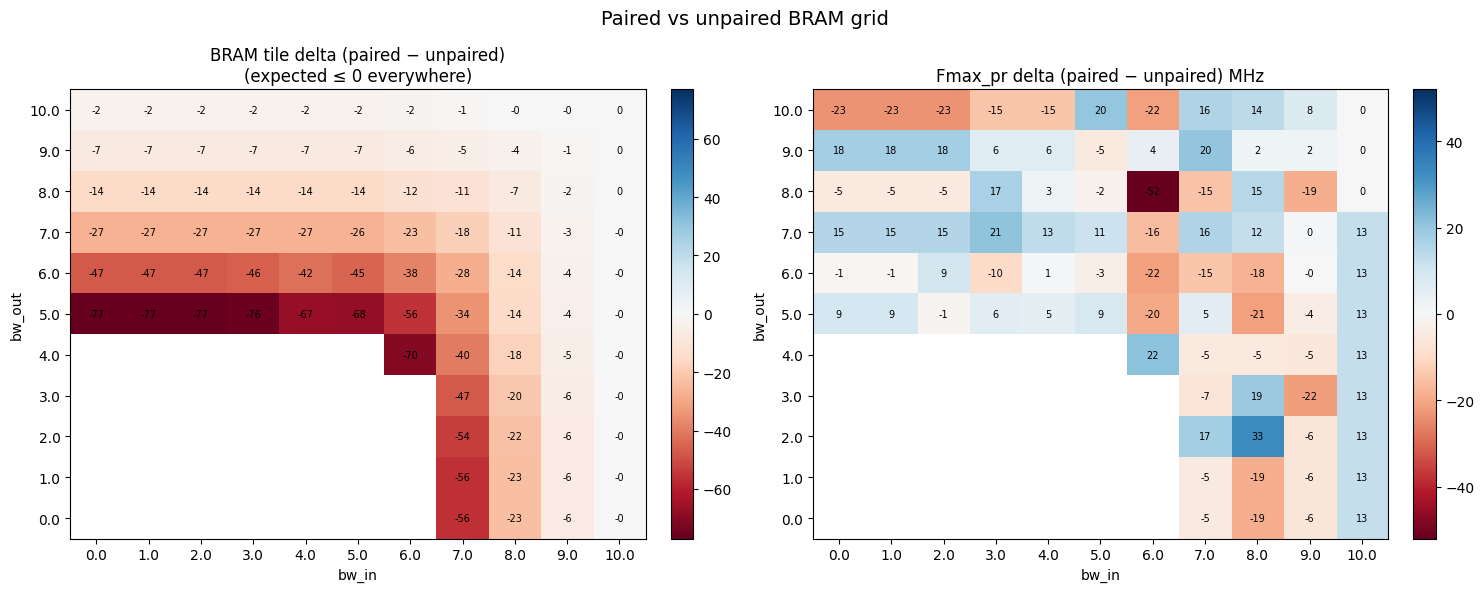

mean BRAM delta = -20.5 tiles  |  mean Fmax delta = +0.9 MHz
Saved bram_paired_vs_unpaired.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not UNPAIRED_CSV.exists():
    print(f'unpaired CSV not found at {UNPAIRED_CSV} — skipping comparison plot.')
else:
    up = pd.read_csv(UNPAIRED_CSV)   # folder,bwin,bwout,...,bram_tile_used,Fmax_MHz,...
    pr = df[df['config'] != 'none'].copy()
    pr['key'] = 'bwin_' + pr['bw_in_threshold'].astype(int).astype(str) + '_bwout_' + pr['bw_out_threshold'].astype(int).astype(str)
    up['key'] = up['folder']
    m = pr.merge(up[['key','bram_tile_used','Fmax_MHz']], on='key', how='inner', suffixes=('','_up'))
    m['bram_delta'] = m['bram_tile'] - m['bram_tile_used']
    m['fmax_delta'] = m['fmax_pr_MHz'] - m['Fmax_MHz']

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, col, title, cmap in [
        (axes[0], 'bram_delta', 'BRAM tile delta (paired − unpaired)\n(expected ≤ 0 everywhere)', 'RdBu'),
        (axes[1], 'fmax_delta', 'Fmax_pr delta (paired − unpaired) MHz', 'RdBu'),
    ]:
        piv = m.pivot(index='bw_out_threshold', columns='bw_in_threshold', values=col).sort_index(ascending=False)
        vals = piv.values.astype(float)
        finite = vals[np.isfinite(vals)]
        a = max(abs(np.nanmin(finite)), abs(np.nanmax(finite)), 1e-6)
        import matplotlib as mpl
        norm = mpl.colors.TwoSlopeNorm(vmin=-a, vcenter=0, vmax=a)
        im = ax.imshow(np.ma.masked_invalid(vals), aspect='auto', cmap=cmap, norm=norm)
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        ax.set_xlabel('bw_in'); ax.set_ylabel('bw_out'); ax.set_title(title)
        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                v = vals[i,j]
                if np.isfinite(v): ax.text(j,i,f'{v:.0f}',ha='center',va='center',fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Paired vs unpaired BRAM grid', fontsize=14)
    plt.tight_layout()
    plt.savefig(NB_DIR / 'bram_paired_vs_unpaired.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'mean BRAM delta = {m["bram_delta"].mean():+.1f} tiles  |  mean Fmax delta = {m["fmax_delta"].mean():+.1f} MHz')
    print('Saved bram_paired_vs_unpaired.png')


Pick the carry-forward operating points (knee + BRAM-heavy) and write `SUMMARY.md`.

In [ ]:
met = df[df['status'] == 'met'].copy()
knee = met[(met['bram_tile'] >= 100) & (met['bram_tile'] <= 150)].sort_values('fmax_pr_MHz', ascending=False)
heavy = met.sort_values('lut_total').head(1)

print('=== Knee candidates (100–150 BRAM tiles, timing-met, by Fmax) ===')
if len(knee):
    print(knee[['config','lut_total','bram_tile','cycles','fmax_pr_MHz','wns_pr']].head(5).to_string(index=False))
    knee_pt = knee.iloc[0]
else:
    print('  none in band; relaxing to highest-Fmax timing-met overall')
    knee_pt = met.sort_values('fmax_pr_MHz', ascending=False).iloc[0]
print('\n=== BRAM-heavy extreme (lowest LUT, timing-met) ===')
print(heavy[['config','lut_total','bram_tile','cycles','fmax_pr_MHz','wns_pr']].to_string(index=False))
heavy_pt = heavy.iloc[0]

print('\n>>> CARRY FORWARD TO FOLDER 2 <<<')
for name, pt in [('KNEE', knee_pt), ('BRAM_HEAVY', heavy_pt)]:
    print(f'  {name}: ({int(pt["bw_in_threshold"])}, {int(pt["bw_out_threshold"])})  '
          f'LUT={pt["lut_total"]:.0f}  BRAM={pt["bram_tile"]:.1f}  cyc={pt["cycles"]:.0f}  '
          f'Fmax_pr={pt["fmax_pr_MHz"]:.1f}  WNS_pr={pt["wns_pr"]:+.3f}')

# ---- write SUMMARY.md -------------------------------------------------------
n_met = int((df['status']=='met').sum())
n_be  = int(df['bit_exact_passed'].sum())
summary = f"""# track1_bram_paired — paired-BRAM mark_bram grid (pair_within_stage=True)

Self-contained writeup of `bram_paired_grid.ipynb`, for the thesis Results chapter.

## Why this experiment exists

Companion to the unpaired BRAM grid (`exhaustive_search/`). Quantifies what the
`pair_within_stage=True` codegen path buys: two same-stage same-geometry ROMs
packed into one RAMB18, cutting BRAM-tile count at zero functional cost.

## Setup

| Knob | Value |
|---|---|
| `CLOCK_PERIOD` | {CLOCK_PERIOD} ns |
| `LATENCY_CUTOFF` | {LATENCY_CUTOFF} ns |
| `HWConfig` | (1, -1, -1) |
| part | {PART_NAME} |
| grid | 11×11 + none = {len(df)} configs |
| `pair_within_stage` | True |
| `MAX_VIVADO_PAR` | 3 |

## Results

- Timing-met: {n_met}/{len(df)} configs.
- Bit-exact (comb.predict vs unmarked baseline): {n_be}/{len(df)} — must be all.
- Verilator (rtl.predict==comb.predict) confirmed on: {VERILATOR_CONFIGS}.

## Operating points worth highlighting

| label | LUT | BRAM | DSP | Cyc | Fmax_pr | WNS_pr | Status |
|---|---|---|---|---|---|---|---|
| knee ({int(knee_pt['bw_in_threshold'])},{int(knee_pt['bw_out_threshold'])}) | {knee_pt['lut_total']:.0f} | {knee_pt['bram_tile']:.1f} | 0 | {knee_pt['cycles']:.0f} | {knee_pt['fmax_pr_MHz']:.1f} | {knee_pt['wns_pr']:+.3f} | met |
| bram-heavy ({int(heavy_pt['bw_in_threshold'])},{int(heavy_pt['bw_out_threshold'])}) | {heavy_pt['lut_total']:.0f} | {heavy_pt['bram_tile']:.1f} | 0 | {heavy_pt['cycles']:.0f} | {heavy_pt['fmax_pr_MHz']:.1f} | {heavy_pt['wns_pr']:+.3f} | met |

## What this experiment establishes

1. Pairing reduces BRAM-tile count vs unpaired (see `bram_paired_vs_unpaired.png`)
   with negligible LUT/FF/Fmax change — a pure backend-mapping win.
2. Cycle count tracks the number of clocked (BRAM) stages, NOT the number of
   promoted lookups — verify the monotonic relationship in the `cycles` heatmap.
3. Every config is bit-exact to the unmarked da4ml output (SW gate + Verilator).

## Honest caveats

- Fill in: any configs that failed placement (status=place_fail) — these are
  LUT-congestion artefacts on xczu7ev's single SLR at low-bwout, not mark bugs.
- The bit-exactness assertion held on all {n_be}/{len(df)} configs.
- Verilator confirmation was run on a representative subset ({VERILATOR_CONFIGS}),
  not all 122, for runtime; the SW bit-exact gate covers all.
"""
(NB_DIR / 'SUMMARY.md').write_text(summary)
print('\nWrote SUMMARY.md')


=== Knee candidates (100–150 BRAM tiles, timing-met, by Fmax) ===
        config  lut_total  bram_tile  cycles  fmax_pr_MHz  wns_pr
bwin_3_bwout_6    31587.0      141.5      29   235.682300   0.757
bwin_5_bwout_6    31171.0      126.0      26   228.623685   0.626
bwin_2_bwout_6    31588.0      143.0      29   227.479527   0.604
bwin_7_bwout_3    31003.0      139.5      26   226.039783   0.576
bwin_4_bwout_6    31505.0      138.5      29   222.172850   0.499

=== BRAM-heavy extreme (lowest LUT, timing-met) ===
        config  lut_total  bram_tile  cycles  fmax_pr_MHz  wns_pr
bwin_6_bwout_3    29382.0      267.5      29   221.092195   0.477

>>> CARRY FORWARD TO FOLDER 2 <<<
  KNEE: (3, 6)  LUT=31587  BRAM=141.5  cyc=29  Fmax_pr=235.7  WNS_pr=+0.757
  BRAM_HEAVY: (6, 3)  LUT=29382  BRAM=267.5  cyc=29  Fmax_pr=221.1  WNS_pr=+0.477

Wrote SUMMARY.md


: 